# First-Time Student Support Services & Course Success Analysis
## San Bernardino Valley College | Academic Year 2024-2025

**Analyst:** Senior Research & Planning Analyst Candidate  
**Date:** March 2026  
**Audience:** Upper Management  

---

### Purpose
This analysis investigates the relationship between **first-time student participation in support services** and **course success outcomes**. We examine patterns across terms, course modalities, demographics, and service types to identify actionable insights for improving student outcomes.

### Key Definitions (per assignment)
- **First-Time Student (FTS):** Any student who has not enrolled in the college for the past three academic years
- **Enrollment Grades:** A, B, C, D, F, P, CR, NP, NC, W, FW, I
- **Completion Grades:** A, B, C, D, F, P, CR, NP, NC
- **Success Grades:** A, B, C, P, CR
- **Failure Grades:** D, F, NP, NC, W

---
## 1. Setup & Data Loading

We load all four provided CSV datasets. No original files are modified — all analysis is read-only.

In [1]:
# ============================================================
# SETUP: Import libraries and configure visualization defaults
# ============================================================
# We use pandas for data manipulation, matplotlib/seaborn for
# presentation-quality charts styled for executive audiences.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Executive-friendly chart styling
sns.set_theme(style='whitegrid', font_scale=1.2)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'figure.dpi': 120,
    'savefig.bbox': 'tight'
})

# SBVC brand-inspired color palette
COLORS = ['#1B3A5C', '#2E86AB', '#A23B72', '#F18F01', '#4CAF50', '#E74C3C']
SUCCESS_FAIL = ['#4CAF50', '#E74C3C']

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ============================================================
# DATA LOADING: Read all four CSV files
# ============================================================
# ASSUMPTION: Files are in the same directory as this notebook.
# We read student IDs as strings to preserve whatever values
# exist (even though they are corrupted — see Section 2).
# ============================================================

demographics = pd.read_csv(
    '3_student_demographics 3(in).csv',
    dtype={'stuid': str}
)

programs = pd.read_csv(
    '3_student_academic_programs_byTerm 3(in).csv',
    dtype={'stuid': str}
)

services = pd.read_csv(
    '2_student_support_services_byTerm 2(in).csv',
    dtype={'stuid': str}
)

grades = pd.read_csv(
    '4_enrollment_grades_byTerm 4(in).csv',
    dtype={'stuid': str}
)

print('All datasets loaded successfully.')
print(f'  Demographics:      {demographics.shape[0]:>8,} rows x {demographics.shape[1]} cols')
print(f'  Academic Programs: {programs.shape[0]:>8,} rows x {programs.shape[1]} cols')
print(f'  Support Services:  {services.shape[0]:>8,} rows x {services.shape[1]} cols')
print(f'  Enrollment/Grades: {grades.shape[0]:>8,} rows x {grades.shape[1]} cols')

All datasets loaded successfully.
  Demographics:        46,481 rows x 4 cols
  Academic Programs:  687,123 rows x 4 cols
  Support Services:   118,468 rows x 3 cols
  Enrollment/Grades:  481,127 rows x 4 cols


---
## 2. Data Profiling & Quality Assessment

In [3]:
# ============================================================
# DATA PROFILING: Examine each dataset's structure and content
# ============================================================
# This step documents column types, missing values, and value
# distributions before any analysis begins.
# ============================================================

datasets = {
    'Demographics': demographics,
    'Academic Programs': programs,
    'Support Services': services,
    'Enrollment & Grades': grades
}

for name, df in datasets.items():
    print(f'\n{"=" * 60}')
    print(f'  {name}')
    print(f'{"=" * 60}')
    print(f'  Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
    print(f'  Columns: {list(df.columns)}')
    print(f'  Missing values:\n{df.isnull().sum().to_string()}' if df.isnull().any().any() else '  Missing values: None')
    print(f'  Unique student IDs: {df["stuid"].nunique()}')
    print(f'  Sample stuid values: {sorted(df["stuid"].unique())[:5]}')
    print()


  Demographics
  Shape: 46,481 rows x 4 columns
  Columns: ['GenderIdentity', 'FirstGenerationStatus', 'Race', 'stuid']
  Missing values: None
  Unique student IDs: 11
  Sample stuid values: ['1.31E+13', '1.32E+13', '1.33E+13', '1.34E+13', '1.41E+13']


  Academic Programs
  Shape: 687,123 rows x 4 columns
  Columns: ['AcademicProgramSTEMStatus', 'AcademicProgramTitle', 'AcedemicProgramActiveTerm', 'stuid']
  Missing values:
AcademicProgramSTEMStatus    754
AcademicProgramTitle         754
AcedemicProgramActiveTerm      0
stuid                          0
  Unique student IDs: 11
  Sample stuid values: ['1.31E+13', '1.32E+13', '1.33E+13', '1.34E+13', '1.41E+13']


  Support Services
  Shape: 118,468 rows x 3 columns
  Columns: ['Term', 'Support_Services', 'stuid']
  Missing values: None
  Unique student IDs: 11
  Sample stuid values: ['1.31E+13', '1.32E+13', '1.33E+13', '1.34E+13', '1.41E+13']


  Enrollment & Grades
  Shape: 481,127 rows x 4 columns
  Columns: ['Term', 'Section_Modali

---
## 2A. CRITICAL DATA QUALITY ISSUE: Corrupted Student IDs

### The Problem
The `stuid` column — which is the **only key to link students across datasets** — has been corrupted by Excel's scientific notation formatting. Original 13-14 digit numeric IDs were truncated to values like `1.41E+13`, reducing **46,481 unique students to only 11 distinct ID values**.

### Impact
- **Cannot reliably join** demographics, services, programs, and grades for individual students
- **Cannot identify first-time students** (requires tracking enrollment history per student)
- **Cannot determine** which specific students used support services vs. did not

### Our Analytical Approach
Despite this limitation, we can still deliver **valuable aggregate insights** by analyzing each dataset independently:
1. **Within-file analyses** — success rates, modality trends, demographic distributions, and service utilization patterns
2. **Population-level comparisons** — overall rates that reveal institutional patterns
3. **Methodology documentation** — exactly what the analysis would look like with clean data (Section 7)

In [4]:
# ============================================================
# DATA QUALITY: Demonstrate the student ID corruption
# ============================================================
# This cell quantifies the scope of the ID problem so
# leadership understands why cross-dataset joins are unreliable.
# ============================================================

print('STUDENT ID CORRUPTION SUMMARY')
print('=' * 50)
for name, df in datasets.items():
    unique_ids = df['stuid'].nunique()
    total_rows = len(df)
    print(f'  {name:<25} {total_rows:>8,} rows  ->  {unique_ids:>3} unique IDs')

print(f'\n  All 11 corrupted ID values:')
all_ids = sorted(demographics['stuid'].unique())
for sid in all_ids:
    count = len(demographics[demographics['stuid'] == sid])
    print(f'    {sid}  ({count:,} students in demographics)')

print(f'\n  Root cause: Excel auto-converted long numeric IDs to scientific notation.')
print(f'  Example: 14100000000000 -> 1.41E+13 (only 3 significant digits retained)')
print(f'  Result: ~46,481 students collapsed into 11 ID buckets — unusable for joins.')

STUDENT ID CORRUPTION SUMMARY
  Demographics                46,481 rows  ->   11 unique IDs
  Academic Programs          687,123 rows  ->   11 unique IDs
  Support Services           118,468 rows  ->   11 unique IDs
  Enrollment & Grades        481,127 rows  ->   11 unique IDs

  All 11 corrupted ID values:
    1.31E+13  (2,900 students in demographics)
    1.32E+13  (1,698 students in demographics)
    1.33E+13  (7,203 students in demographics)
    1.34E+13  (822 students in demographics)
    1.41E+13  (12,653 students in demographics)
    1.43E+13  (1,665 students in demographics)
    1.44E+13  (14,460 students in demographics)
    2.61E+13  (935 students in demographics)
    2.62E+13  (1,216 students in demographics)
    2.63E+13  (2,765 students in demographics)
    2.64E+13  (164 students in demographics)

  Root cause: Excel auto-converted long numeric IDs to scientific notation.
  Example: 14100000000000 -> 1.41E+13 (only 3 significant digits retained)
  Result: ~46,481 students

---
## 3. Grade Classification & Success Rate Analysis

We classify every enrollment record using the definitions provided, then analyze success rates across terms.

In [5]:
# ============================================================
# GRADE CLASSIFICATION: Apply assignment-defined categories
# ============================================================
# Each grade is tagged as Success, Completion (but not success),
# or Non-completion using the exact definitions from the README.
#
# ASSUMPTION: Empty/blank grades (2 records) are excluded as
# they represent data entry errors, not student outcomes.
# ============================================================

SUCCESS_GRADES = {'A', 'B', 'C', 'P', 'CR'}
COMPLETION_GRADES = {'A', 'B', 'C', 'D', 'F', 'P', 'CR', 'NP', 'NC'}
ENROLLMENT_GRADES = {'A', 'B', 'C', 'D', 'F', 'P', 'CR', 'NP', 'NC', 'W', 'FW', 'I'}

# Work on a copy to avoid modifying the loaded data
g = grades.copy()

# Remove blank grades (only 2 records)
g = g[g['Section_Final_Grade'].str.strip() != ''].copy()

# Classify outcomes
g['is_success'] = g['Section_Final_Grade'].isin(SUCCESS_GRADES)
g['is_completion'] = g['Section_Final_Grade'].isin(COMPLETION_GRADES)
g['is_enrollment'] = g['Section_Final_Grade'].isin(ENROLLMENT_GRADES)

# Create a readable outcome category for charts
def classify_outcome(grade):
    if grade in SUCCESS_GRADES:
        return 'Success (A/B/C/P/CR)'
    elif grade in {'D', 'F', 'NP', 'NC'}:
        return 'Completed - Not Successful'
    elif grade in {'W', 'FW'}:
        return 'Withdrawn (W/FW)'
    elif grade == 'I':
        return 'Incomplete'
    else:
        return 'Other'

g['outcome_category'] = g['Section_Final_Grade'].apply(classify_outcome)

print('Grade Classification Summary')
print('=' * 50)
print(f'  Total enrollment records: {len(g):,}')
print(f'  Success rate:     {g["is_success"].mean():.1%}')
print(f'  Completion rate:  {g["is_completion"].mean():.1%}')
print(f'\nGrade distribution:')
grade_dist = g['Section_Final_Grade'].value_counts()
for grade, count in grade_dist.items():
    pct = count / len(g) * 100
    cat = 'Success' if grade in SUCCESS_GRADES else ('Fail' if grade in {'D','F','NP','NC'} else 'W/Other')
    print(f'    {grade:>3}  {count:>7,}  ({pct:5.1f}%)  [{cat}]')

Grade Classification Summary
  Total enrollment records: 481,127
  Success rate:     71.1%
  Completion rate:  88.6%

Grade distribution:
      A  189,994  ( 39.5%)  [Success]
      B   87,125  ( 18.1%)  [Success]
      F   60,400  ( 12.6%)  [Fail]
      W   53,321  ( 11.1%)  [W/Other]
      C   47,675  (  9.9%)  [Success]
      P   17,494  (  3.6%)  [Success]
      D   16,359  (  3.4%)  [Fail]
     NP    6,945  (  1.4%)  [Fail]
     FW    1,414  (  0.3%)  [W/Other]
     NC      250  (  0.1%)  [Fail]
      I      148  (  0.0%)  [W/Other]


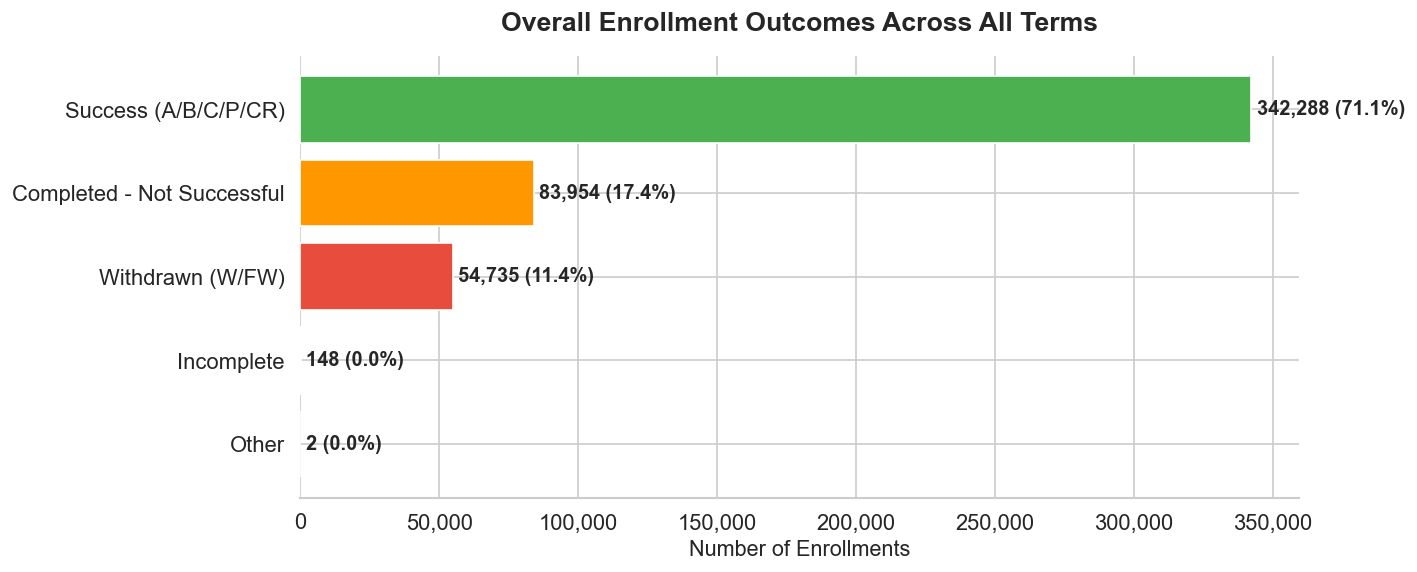

In [6]:
# ============================================================
# CHART 1: Overall Grade Distribution (Treemap-style bar)
# ============================================================
# METHOD: Simple value counts of final grades, grouped by
# outcome category. Gives leadership a quick snapshot of how
# enrollments resolve across the institution.
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

outcome_counts = g['outcome_category'].value_counts()
color_map = {
    'Success (A/B/C/P/CR)': '#4CAF50',
    'Completed - Not Successful': '#FF9800',
    'Withdrawn (W/FW)': '#E74C3C',
    'Incomplete': '#9E9E9E'
}
colors = [color_map.get(cat, '#999') for cat in outcome_counts.index]

bars = ax.barh(outcome_counts.index, outcome_counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, outcome_counts.values):
    pct = val / len(g) * 100
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({pct:.1f}%)', va='center', fontsize=12, fontweight='bold')

ax.set_title('Overall Enrollment Outcomes Across All Terms', pad=15)
ax.set_xlabel('Number of Enrollments')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.invert_yaxis()
sns.despine(left=True)
plt.tight_layout()
plt.show()

---
## 4. Success & Completion Rates by Term

In [7]:
# ============================================================
# TERM ANALYSIS: Calculate success and completion rates per term
# ============================================================
# METHOD: Group enrollment records by term, compute the
# proportion classified as "success" and "completion."
#
# ASSUMPTION: Terms are sorted chronologically. Term codes
# follow the pattern YYYYxx where xx = SP/SM/FA.
# We define a sort key: year * 10 + season_order.
# ============================================================

def term_sort_key(term):
    """Convert term codes like '2024FA' to sortable integers."""
    year = int(term[:4])
    season = term[4:]
    season_order = {'SP': 0, 'SM': 1, 'FA': 2}
    return year * 10 + season_order.get(season, 9)

term_stats = g.groupby('Term').agg(
    enrollments=('is_success', 'count'),
    success_rate=('is_success', 'mean'),
    completion_rate=('is_completion', 'mean')
).reset_index()

term_stats['sort_key'] = term_stats['Term'].apply(term_sort_key)
term_stats = term_stats.sort_values('sort_key')

# Flag primary terms (Fall/Spring) vs summer
term_stats['is_summer'] = term_stats['Term'].str.contains('SM')

print('Success & Completion Rates by Term')
print('=' * 65)
for _, row in term_stats.iterrows():
    flag = ' (Summer)' if row['is_summer'] else ''
    print(f"  {row['Term']}{flag:<10}  Enrollments: {row['enrollments']:>6,}  "
          f"Success: {row['success_rate']:.1%}  Completion: {row['completion_rate']:.1%}")

Success & Completion Rates by Term
  2021SM (Summer)   Enrollments: 14,355  Success: 72.7%  Completion: 88.0%
  2021FA            Enrollments: 42,596  Success: 64.2%  Completion: 86.0%
  2022SP            Enrollments: 44,031  Success: 70.0%  Completion: 87.5%
  2022SM (Summer)   Enrollments: 13,449  Success: 74.4%  Completion: 88.0%
  2022FA            Enrollments: 46,312  Success: 67.4%  Completion: 87.4%
  2023SP            Enrollments: 47,933  Success: 72.2%  Completion: 88.6%
  2023SM (Summer)   Enrollments: 18,964  Success: 75.3%  Completion: 88.4%
  2023FA            Enrollments: 55,445  Success: 69.0%  Completion: 88.2%
  2024SP            Enrollments: 56,055  Success: 72.0%  Completion: 90.1%
  2024SM (Summer)   Enrollments: 19,846  Success: 74.4%  Completion: 89.1%
  2024FA            Enrollments: 60,277  Success: 70.8%  Completion: 89.2%
  2025SP            Enrollments: 61,864  Success: 76.8%  Completion: 90.6%


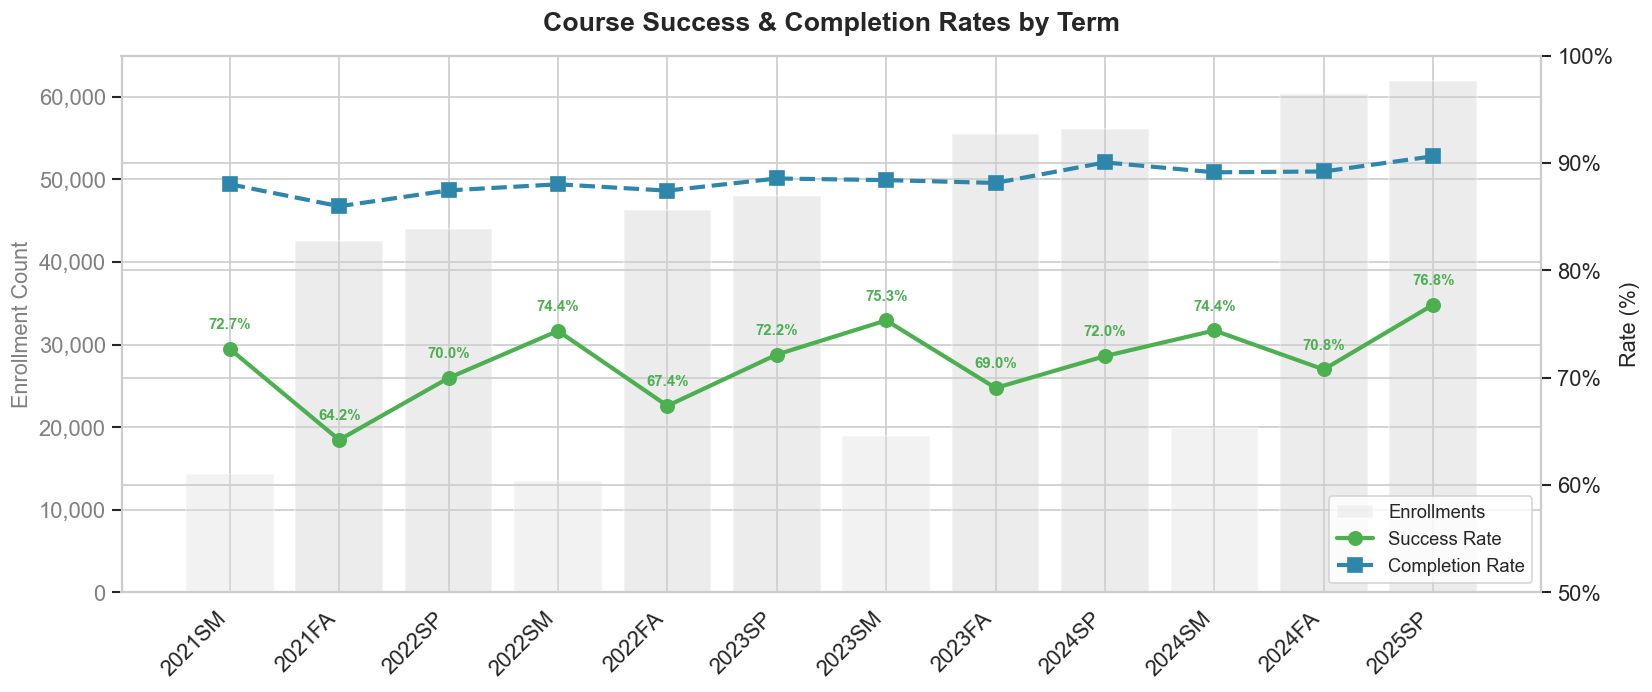

In [8]:
# ============================================================
# CHART 2: Success & Completion Rate Trends Over Time
# ============================================================
# METHOD: Dual-line chart with enrollment volume as bar
# background. Summer terms are visually distinguished since
# they have different enrollment patterns and student mix.
# ============================================================

fig, ax1 = plt.subplots(figsize=(14, 6))

x = range(len(term_stats))
labels = term_stats['Term'].values

# Bar chart for enrollment volume (background context)
bar_colors = ['#E0E0E0' if s else '#D0D0D0' for s in term_stats['is_summer']]
ax1.bar(x, term_stats['enrollments'], color=bar_colors, alpha=0.4, label='Enrollments')
ax1.set_ylabel('Enrollment Count', color='gray')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.tick_params(axis='y', labelcolor='gray')

# Line charts for rates on secondary axis
ax2 = ax1.twinx()
ax2.plot(x, term_stats['success_rate'] * 100, 'o-', color='#4CAF50',
         linewidth=2.5, markersize=8, label='Success Rate', zorder=5)
ax2.plot(x, term_stats['completion_rate'] * 100, 's--', color='#2E86AB',
         linewidth=2.5, markersize=8, label='Completion Rate', zorder=5)

# Add percentage labels on the success line
for i, (sr, cr) in enumerate(zip(term_stats['success_rate'], term_stats['completion_rate'])):
    ax2.annotate(f'{sr:.1%}', (i, sr*100), textcoords='offset points',
                 xytext=(0, 12), ha='center', fontsize=9, fontweight='bold', color='#4CAF50')

ax2.set_ylabel('Rate (%)')
ax2.set_ylim(50, 100)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right')
ax1.set_title('Course Success & Completion Rates by Term', pad=15)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

---
## 5. Success Rates by Course Modality

In [9]:
# ============================================================
# MODALITY ANALYSIS: Success rates by delivery format
# ============================================================
# METHOD: Group enrollments by Section_Modality, compute
# success rate and withdrawal rate for each.
#
# This is a within-file analysis (grades file only) so it is
# NOT affected by the student ID corruption.
#
# ASSUMPTION: Modality labels reflect the primary delivery
# method. Combined labels (e.g., "In-Person & Online") likely
# indicate sections with multiple delivery components.
# ============================================================

modality_stats = g.groupby('Section_Modality').agg(
    enrollments=('is_success', 'count'),
    success_rate=('is_success', 'mean'),
    completion_rate=('is_completion', 'mean'),
    withdrawal_rate=('Section_Final_Grade', lambda x: x.isin({'W', 'FW'}).mean())
).reset_index()

modality_stats = modality_stats.sort_values('success_rate', ascending=True)

print('Success Rates by Course Modality')
print('=' * 80)
for _, row in modality_stats.iterrows():
    print(f"  {row['Section_Modality']:<35} N={row['enrollments']:>7,}  "
          f"Success: {row['success_rate']:.1%}  "
          f"Withdraw: {row['withdrawal_rate']:.1%}")

Success Rates by Course Modality
  In-Person & Hybrid                  N= 15,451  Success: 62.3%  Withdraw: 13.3%
  Online                              N=165,106  Success: 69.1%  Withdraw: 12.8%
  In-Person, Hybrid, and Online       N= 76,493  Success: 70.9%  Withdraw: 10.9%
  Hybrid & Online                     N= 51,917  Success: 72.2%  Withdraw: 11.8%
  In-Person & Online                  N=119,586  Success: 72.8%  Withdraw: 10.2%
  In-Person                           N= 41,342  Success: 75.2%  Withdraw: 9.4%
  Hybrid                              N= 11,232  Success: 78.0%  Withdraw: 9.2%


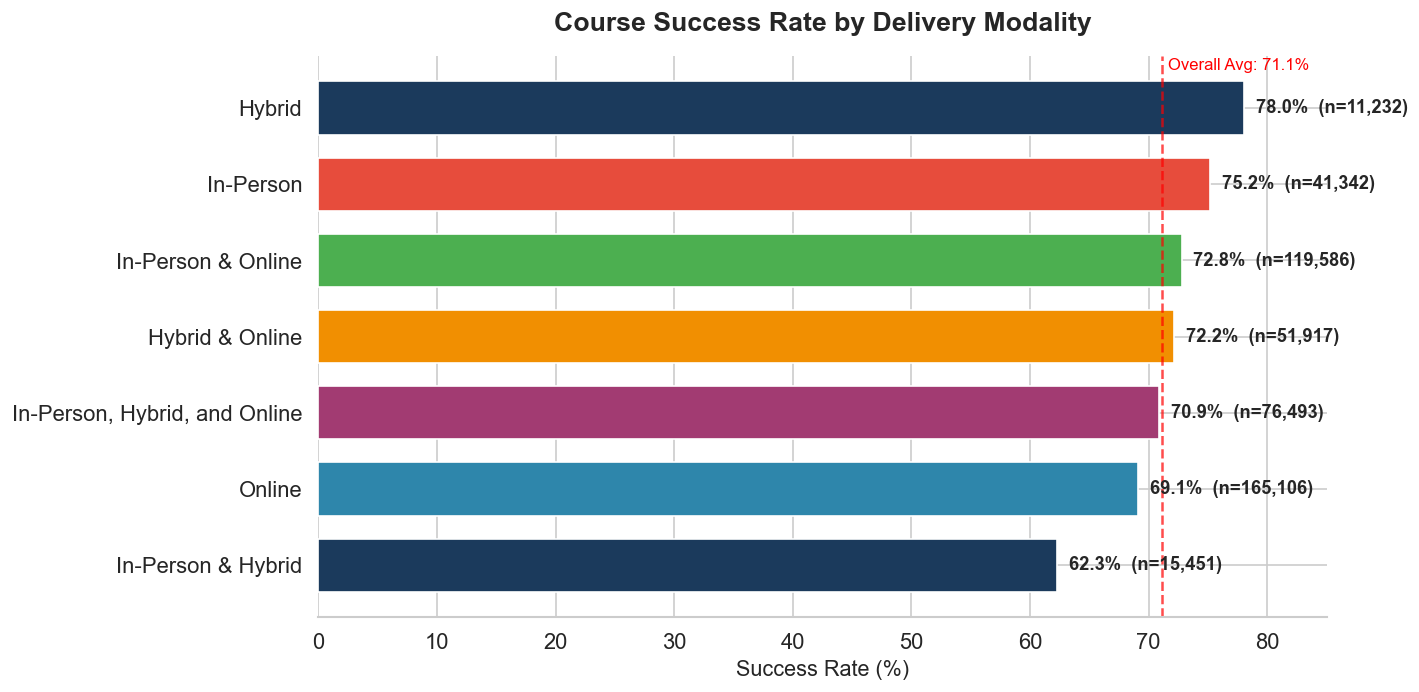

In [10]:
# ============================================================
# CHART 3: Success Rate by Modality (Horizontal bar)
# ============================================================
# METHOD: Horizontal bar chart sorted by success rate,
# with enrollment counts annotated for context. This format
# makes it easy for management to see which modalities perform
# best and which have enough volume to be meaningful.
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

y_pos = range(len(modality_stats))
bars = ax.barh(y_pos, modality_stats['success_rate'] * 100,
               color=COLORS[:len(modality_stats)], edgecolor='white', height=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels(modality_stats['Section_Modality'])
ax.set_xlabel('Success Rate (%)')
ax.set_title('Course Success Rate by Delivery Modality', pad=15)
ax.set_xlim(0, 85)

# Add rate labels and enrollment counts
for i, (_, row) in enumerate(modality_stats.iterrows()):
    ax.text(row['success_rate'] * 100 + 1, i,
            f"{row['success_rate']:.1%}  (n={row['enrollments']:,})",
            va='center', fontsize=11, fontweight='bold')

# Add overall average line
overall_sr = g['is_success'].mean() * 100
ax.axvline(x=overall_sr, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(overall_sr + 0.5, len(modality_stats) - 0.5,
        f'Overall Avg: {overall_sr:.1f}%', color='red', fontsize=10)

sns.despine(left=True)
plt.tight_layout()
plt.show()

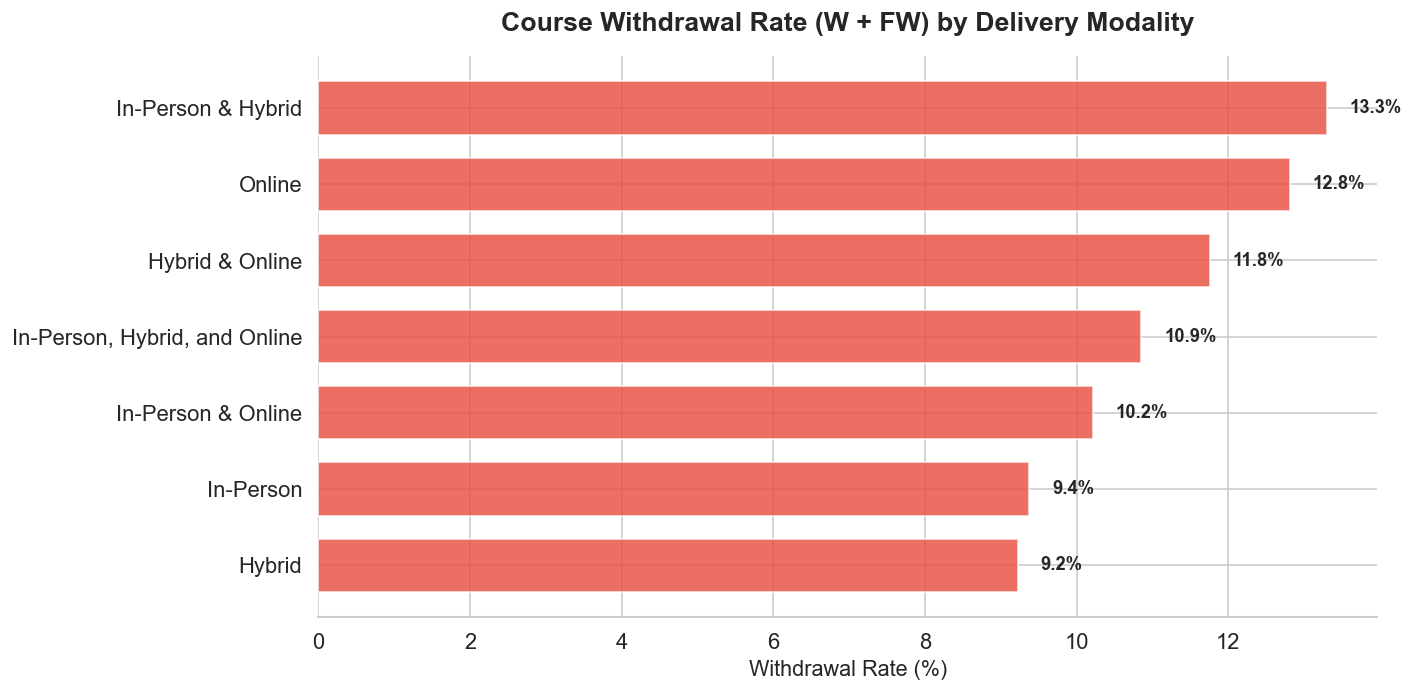

In [11]:
# ============================================================
# CHART 4: Withdrawal Rate by Modality
# ============================================================
# METHOD: Separate chart for withdrawals since this is a key
# equity and retention metric. High withdrawal in a modality
# may signal that students need additional support structures.
# ============================================================

mod_sorted_w = modality_stats.sort_values('withdrawal_rate', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(mod_sorted_w)), mod_sorted_w['withdrawal_rate'] * 100,
               color='#E74C3C', alpha=0.8, edgecolor='white', height=0.7)

ax.set_yticks(range(len(mod_sorted_w)))
ax.set_yticklabels(mod_sorted_w['Section_Modality'])
ax.set_xlabel('Withdrawal Rate (%)')
ax.set_title('Course Withdrawal Rate (W + FW) by Delivery Modality', pad=15)

for i, (_, row) in enumerate(mod_sorted_w.iterrows()):
    ax.text(row['withdrawal_rate'] * 100 + 0.3, i,
            f"{row['withdrawal_rate']:.1%}", va='center', fontsize=11, fontweight='bold')

sns.despine(left=True)
plt.tight_layout()
plt.show()

---
## 6. Demographic Profile & Success Patterns

In [12]:
# ============================================================
# DEMOGRAPHIC PROFILING: Student population composition
# ============================================================
# METHOD: Frequency counts and percentages from the
# demographics file. This is a within-file analysis and does
# NOT require joining to other datasets.
#
# NOTE: These are student-level counts (one row per student).
# The demographics file has 46,481 rows representing the
# full student population in the data.
# ============================================================

print('STUDENT POPULATION DEMOGRAPHICS')
print('=' * 55)

print('\nGender Identity:')
for val, count in demographics['GenderIdentity'].value_counts().items():
    print(f'  {val:<25} {count:>6,}  ({count/len(demographics)*100:5.1f}%)')

print('\nFirst-Generation Status:')
for val, count in demographics['FirstGenerationStatus'].value_counts().items():
    label = {'Y': 'Yes', 'N': 'No'}.get(val, val)
    print(f'  {label:<25} {count:>6,}  ({count/len(demographics)*100:5.1f}%)')

print('\nRace/Ethnicity:')
for val, count in demographics['Race'].value_counts().items():
    print(f'  {val:<35} {count:>6,}  ({count/len(demographics)*100:5.1f}%)')

STUDENT POPULATION DEMOGRAPHICS

Gender Identity:
  Female                    27,185  ( 58.5%)
  Male                      18,649  ( 40.1%)
  Decline to state             405  (  0.9%)
  Non-binary                   242  (  0.5%)

First-Generation Status:
  Yes                       22,123  ( 47.6%)
  No                        19,996  ( 43.0%)
  Unknown/Unreported         4,362  (  9.4%)

Race/Ethnicity:
  Hispanic                            31,469  ( 67.7%)
  White                                5,474  ( 11.8%)
  Black/African American               4,973  ( 10.7%)
  Asian                                2,025  (  4.4%)
  Two or More Races                    1,767  (  3.8%)
  Unknown/Unreported                     292  (  0.6%)
  Filipino                               244  (  0.5%)
  Pacific Islander/Hawaiian Native       153  (  0.3%)
  Native American/Alaskan Native          84  (  0.2%)


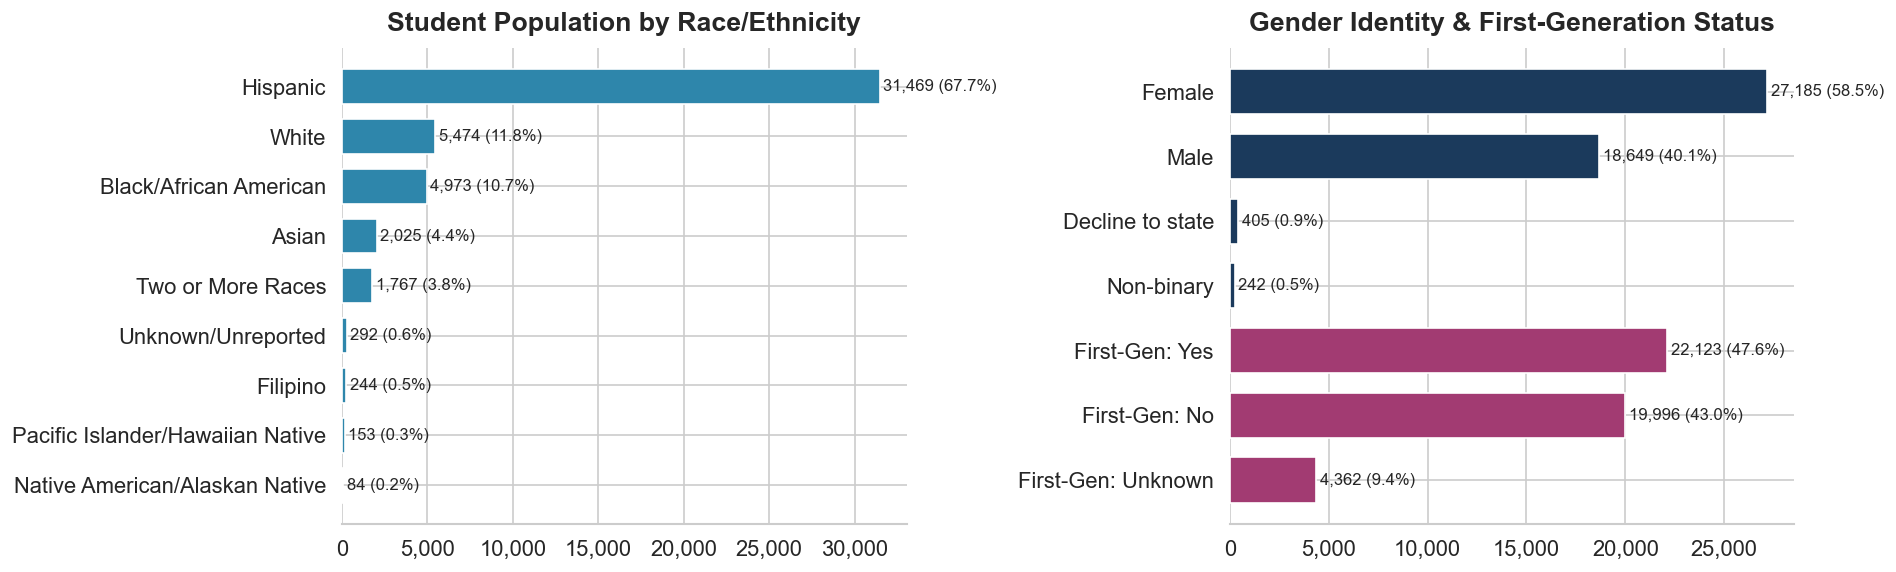

In [13]:
# ============================================================
# CHART 5: Student Population by Race/Ethnicity
# ============================================================
# METHOD: Horizontal bar chart of demographic composition.
# Important context for leadership to understand the student
# body they serve. Hispanic students are the clear majority.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Race/Ethnicity
race_counts = demographics['Race'].value_counts()
bars = axes[0].barh(range(len(race_counts)), race_counts.values,
                    color='#2E86AB', edgecolor='white', height=0.7)
axes[0].set_yticks(range(len(race_counts)))
axes[0].set_yticklabels(race_counts.index)
axes[0].set_title('Student Population by Race/Ethnicity', pad=10)
axes[0].invert_yaxis()
for i, (val, count) in enumerate(race_counts.items()):
    axes[0].text(count + 200, i, f'{count:,} ({count/len(demographics)*100:.1f}%)',
                 va='center', fontsize=10)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Gender and First-Gen side by side
gender_counts = demographics['GenderIdentity'].value_counts()
firstgen_counts = demographics['FirstGenerationStatus'].value_counts()
firstgen_counts.index = firstgen_counts.index.map({'Y': 'First-Gen: Yes', 'N': 'First-Gen: No',
                                                    'Unknown/Unreported': 'First-Gen: Unknown'})

combined = pd.concat([gender_counts, firstgen_counts])
colors_combined = ['#1B3A5C'] * len(gender_counts) + ['#A23B72'] * len(firstgen_counts)
bars = axes[1].barh(range(len(combined)), combined.values,
                    color=colors_combined, edgecolor='white', height=0.7)
axes[1].set_yticks(range(len(combined)))
axes[1].set_yticklabels(combined.index)
axes[1].set_title('Gender Identity & First-Generation Status', pad=10)
axes[1].invert_yaxis()
for i, count in enumerate(combined.values):
    axes[1].text(count + 200, i, f'{count:,} ({count/len(demographics)*100:.1f}%)',
                 va='center', fontsize=10)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

for ax in axes:
    sns.despine(ax=ax, left=True)

plt.tight_layout()
plt.show()

---
## 6A. Support Services Utilization Patterns

In [14]:
# ============================================================
# SUPPORT SERVICES: Utilization volume and trends
# ============================================================
# METHOD: Analyze the support services file independently.
# Each row represents one student-term-service interaction.
#
# KEY INSIGHT: Even without clean IDs, we can see which
# services have the highest utilization and how usage trends
# over time. This helps leadership understand program reach.
# ============================================================

print('SUPPORT SERVICES OVERVIEW')
print('=' * 60)
print(f'Total service interactions: {len(services):,}')
print(f'\nService Utilization (student-term interactions):')
for svc, count in services['Support_Services'].value_counts().items():
    pct = count / len(services) * 100
    print(f'  {svc:<55} {count:>6,}  ({pct:.1f}%)')

SUPPORT SERVICES OVERVIEW
Total service interactions: 118,468

Service Utilization (student-term interactions):
  EOPS                                                    43,343  (36.6%)
  Free College Promise Program                            23,027  (19.4%)
  MESA - Mathematics, Engineering, Science Achievement    19,839  (16.7%)
  CCAP - College and Career Access Pathways               14,252  (12.0%)
  CalWORKs                                                11,451  (9.7%)
  STAR Program                                             6,556  (5.5%)


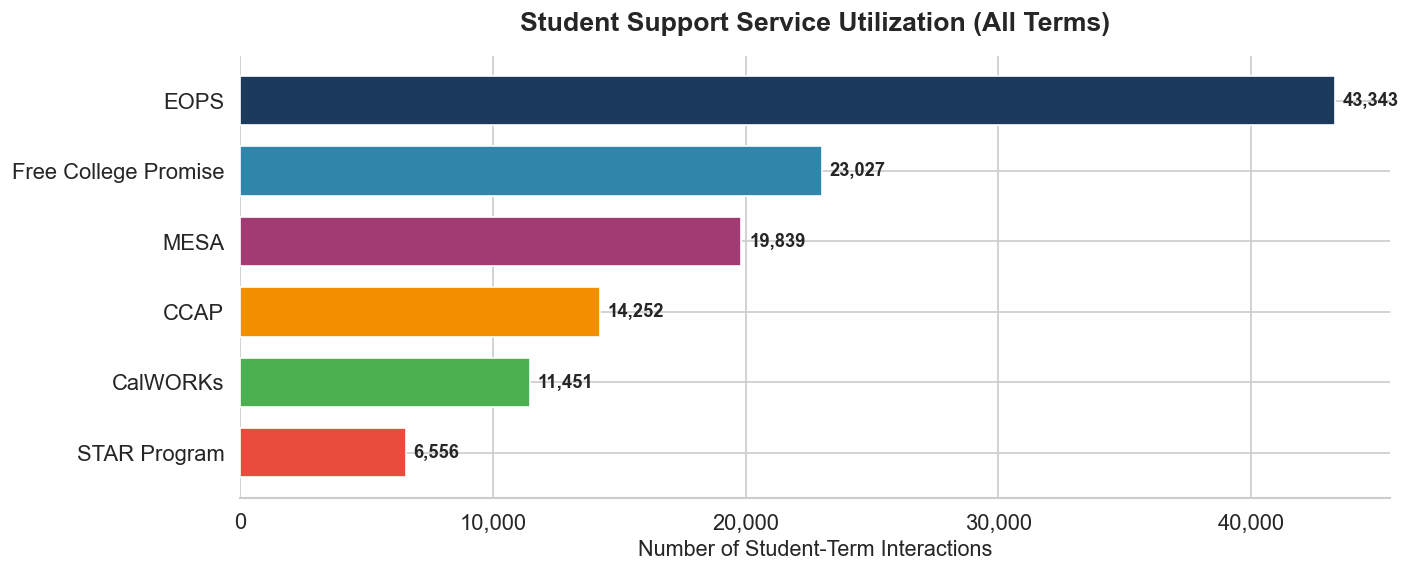

In [15]:
# ============================================================
# CHART 6: Support Service Utilization by Type
# ============================================================
# METHOD: Simple bar chart showing total interactions per
# service across all terms. EOPS dominates, followed by
# Free College Promise.
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

svc_counts = services['Support_Services'].value_counts()
# Shorten labels for readability
short_labels = {
    'MESA - Mathematics, Engineering, Science Achievement': 'MESA',
    'Free College Promise Program': 'Free College Promise',
    'CCAP - College and Career Access Pathways': 'CCAP',
    'EOPS': 'EOPS',
    'CalWORKs': 'CalWORKs',
    'STAR Program': 'STAR Program'
}
display_labels = [short_labels.get(s, s) for s in svc_counts.index]

bars = ax.barh(range(len(svc_counts)), svc_counts.values,
               color=COLORS[:len(svc_counts)], edgecolor='white', height=0.7)
ax.set_yticks(range(len(svc_counts)))
ax.set_yticklabels(display_labels)
ax.invert_yaxis()
ax.set_title('Student Support Service Utilization (All Terms)', pad=15)
ax.set_xlabel('Number of Student-Term Interactions')

for i, count in enumerate(svc_counts.values):
    ax.text(count + 300, i, f'{count:,}', va='center', fontsize=11, fontweight='bold')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
sns.despine(left=True)
plt.tight_layout()
plt.show()

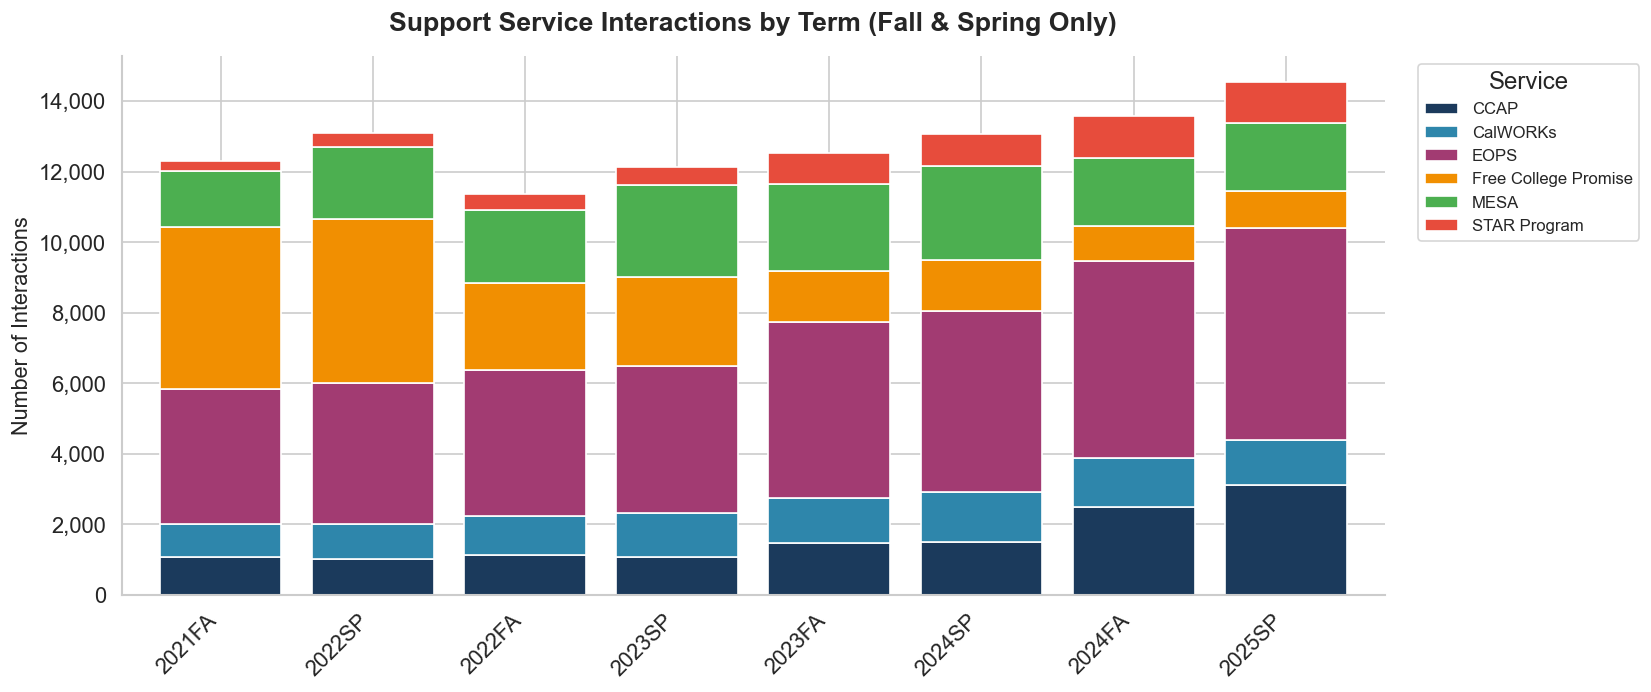

In [16]:
# ============================================================
# CHART 7: Support Service Utilization Trends by Term
# ============================================================
# METHOD: Stacked area chart showing how each service's usage
# has changed over time. This reveals growth patterns and
# helps leadership see which programs are scaling up.
#
# ASSUMPTION: We exclude summer terms for cleaner trend lines
# since summer enrollment is structurally lower.
# ============================================================

# Pivot: term x service
svc_by_term = services.groupby(['Term', 'Support_Services']).size().unstack(fill_value=0)
svc_by_term.columns = [short_labels.get(c, c) for c in svc_by_term.columns]

# Sort terms chronologically
svc_by_term['sort_key'] = svc_by_term.index.map(term_sort_key)
svc_by_term = svc_by_term.sort_values('sort_key')
svc_by_term = svc_by_term.drop(columns='sort_key')

# Filter to primary terms only (Fall/Spring)
primary_terms = svc_by_term[~svc_by_term.index.str.contains('SM')]

fig, ax = plt.subplots(figsize=(14, 6))
primary_terms.plot(kind='bar', stacked=True, ax=ax, color=COLORS, edgecolor='white', width=0.8)
ax.set_title('Support Service Interactions by Term (Fall & Spring Only)', pad=15)
ax.set_ylabel('Number of Interactions')
ax.set_xlabel('')
ax.set_xticklabels(primary_terms.index, rotation=45, ha='right')
ax.legend(title='Service', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

sns.despine()
plt.tight_layout()
plt.show()

---
## 6B. Academic Program & STEM Analysis

In [17]:
# ============================================================
# ACADEMIC PROGRAMS: STEM vs Non-STEM distribution
# ============================================================
# METHOD: Analyze the programs file to show STEM enrollment
# patterns and top program areas. Each row is a student-term-
# program record.
#
# NOTE: This file has 687K+ rows because students can have
# multiple program records across terms.
# ============================================================

print('ACADEMIC PROGRAM OVERVIEW')
print('=' * 55)
print(f'Total program-term records: {len(programs):,}')

print('\nSTEM Status Distribution:')
stem = programs['AcademicProgramSTEMStatus'].value_counts()
for val, count in stem.items():
    if val:  # skip blank
        print(f'  {val:<25} {count:>7,}  ({count/len(programs)*100:.1f}%)')

print(f'\nTop 15 Academic Programs (by enrollment-terms):')
for val, count in programs['AcademicProgramTitle'].value_counts().head(15).items():
    print(f'  {val:<50} {count:>6,}')

ACADEMIC PROGRAM OVERVIEW
Total program-term records: 687,123

STEM Status Distribution:
  Non-STEM                  580,068  (84.4%)
  STEM                       93,211  (13.6%)
  No Active SBVC Program     11,028  (1.6%)
  No Active Program           2,062  (0.3%)

Top 15 Academic Programs (by enrollment-terms):
  Nursing                                            87,593
  Undecided                                          40,401
  Business Administration                            39,863
  Psychology                                         33,113
  Biology                                            29,080
  Liberal Arts: Biological & Physical Sciences       24,113
  Administration of Justice                          21,342
  California State University General Education - Breadth 19,983
  Computer Science                                   19,499
  Business Administration 2.0                        16,138
  Liberal Arts: Social & Behavioral Sciences         16,136
  Kinesiology      

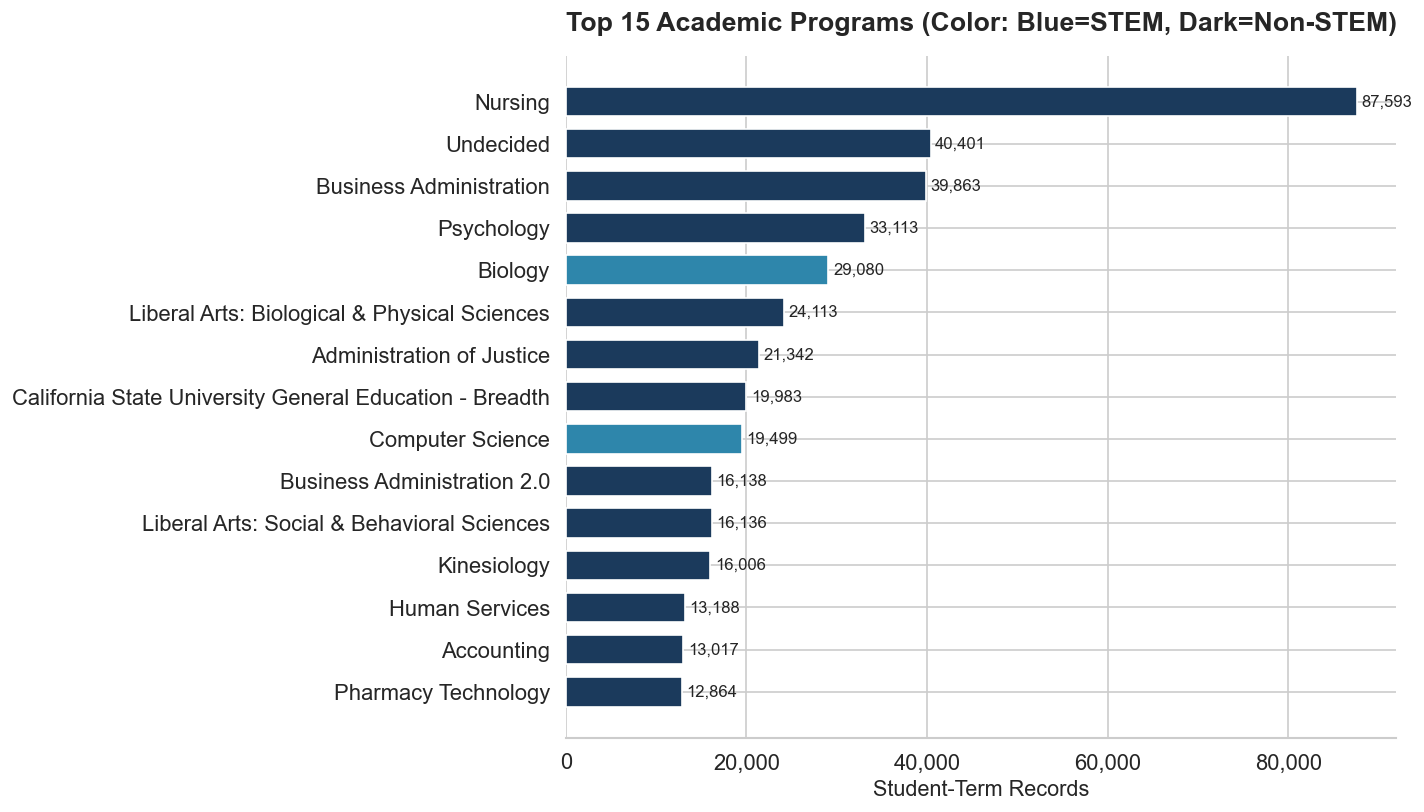

In [18]:
# ============================================================
# CHART 8: Top 15 Academic Programs
# ============================================================
# METHOD: Horizontal bar chart of the most popular programs,
# color-coded by STEM status. Helps leadership understand
# where students concentrate.
# ============================================================

top_programs = programs['AcademicProgramTitle'].value_counts().head(15)

# Get STEM status for each program (use mode/most common)
prog_stem = programs.groupby('AcademicProgramTitle')['AcademicProgramSTEMStatus'].agg(
    lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'Unknown'
)

fig, ax = plt.subplots(figsize=(12, 7))
stem_colors = {'STEM': '#2E86AB', 'Non-STEM': '#1B3A5C',
               'No Active Program': '#9E9E9E', 'No Active SBVC Program': '#9E9E9E'}
bar_colors = [stem_colors.get(prog_stem.get(p, ''), '#999') for p in top_programs.index]

bars = ax.barh(range(len(top_programs)), top_programs.values,
               color=bar_colors, edgecolor='white', height=0.7)
ax.set_yticks(range(len(top_programs)))
ax.set_yticklabels(top_programs.index)
ax.invert_yaxis()
ax.set_title('Top 15 Academic Programs (Color: Blue=STEM, Dark=Non-STEM)', pad=15)
ax.set_xlabel('Student-Term Records')

for i, count in enumerate(top_programs.values):
    ax.text(count + 500, i, f'{count:,}', va='center', fontsize=10)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
sns.despine(left=True)
plt.tight_layout()
plt.show()

---
## 6C. Success Rates by Term — Focusing on AY 2024-2025

In [19]:
# ============================================================
# AY 2024-2025 FOCUS: Detailed success analysis
# ============================================================
# METHOD: The assignment asks specifically about AY 2024-2025
# first-time students. While we cannot isolate FTS due to the
# ID corruption, we CAN examine the overall institutional
# performance for 2024FA and 2025SP terms, which is when
# most AY 24-25 FTS would be enrolling.
#
# ASSUMPTION: AY 2024-2025 = Fall 2024 + Spring 2025 + Summer 2024
# ============================================================

ay_2425_terms = ['2024FA', '2025SP', '2024SM']
g_ay = g[g['Term'].isin(ay_2425_terms)].copy()

print('AY 2024-2025 ENROLLMENT OUTCOMES')
print('=' * 55)
print(f'Total enrollments in AY 24-25: {len(g_ay):,}')
print(f'  Success rate:    {g_ay["is_success"].mean():.1%}')
print(f'  Completion rate: {g_ay["is_completion"].mean():.1%}')
print(f'  Withdrawal rate: {g_ay["Section_Final_Grade"].isin({"W","FW"}).mean():.1%}')

print('\nBy Term within AY 24-25:')
for term in ['2024SM', '2024FA', '2025SP']:
    t = g_ay[g_ay['Term'] == term]
    if len(t) > 0:
        print(f'  {term}: N={len(t):>6,}  Success={t["is_success"].mean():.1%}  '
              f'Completion={t["is_completion"].mean():.1%}')

print('\nBy Modality within AY 24-25:')
for mod, grp in g_ay.groupby('Section_Modality'):
    print(f'  {mod:<35} N={len(grp):>6,}  Success={grp["is_success"].mean():.1%}')

AY 2024-2025 ENROLLMENT OUTCOMES
Total enrollments in AY 24-25: 141,987
  Success rate:    73.9%
  Completion rate: 89.8%
  Withdrawal rate: 10.1%

By Term within AY 24-25:
  2024SM: N=19,846  Success=74.4%  Completion=89.1%
  2024FA: N=60,277  Success=70.8%  Completion=89.2%
  2025SP: N=61,864  Success=76.8%  Completion=90.6%

By Modality within AY 24-25:
  Hybrid                              N= 4,611  Success=81.1%
  Hybrid & Online                     N=14,984  Success=76.6%
  In-Person                           N=14,095  Success=73.4%
  In-Person & Hybrid                  N= 6,423  Success=64.0%
  In-Person & Online                  N=36,976  Success=74.8%
  In-Person, Hybrid, and Online       N=25,151  Success=73.9%
  Online                              N=39,747  Success=73.0%


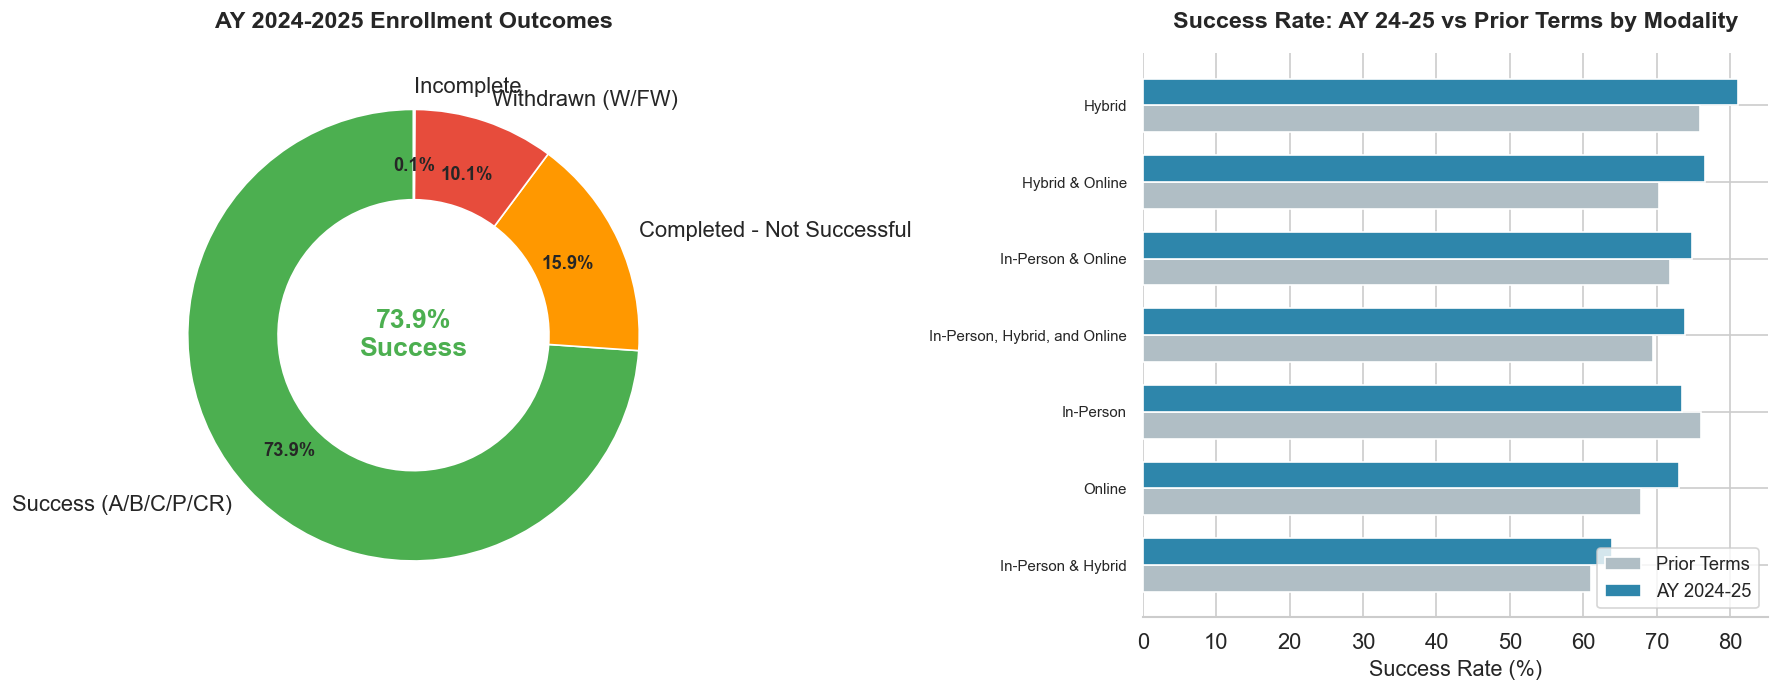

In [20]:
# ============================================================
# CHART 9: AY 2024-2025 Grade Distribution (Donut Chart)
# ============================================================
# METHOD: Donut/pie chart showing the breakdown of outcomes
# specifically for AY 24-25. The center annotation highlights
# the overall success rate — the single most important number
# for leadership.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Donut chart for AY 24-25 outcomes
outcome_ay = g_ay['outcome_category'].value_counts()
colors_pie = ['#4CAF50', '#FF9800', '#E74C3C', '#9E9E9E']
wedges, texts, autotexts = axes[0].pie(
    outcome_ay.values, labels=outcome_ay.index, colors=colors_pie[:len(outcome_ay)],
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white'))
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
axes[0].set_title('AY 2024-2025 Enrollment Outcomes', pad=15, fontsize=14, fontweight='bold')

# Center text
sr = g_ay['is_success'].mean()
axes[0].text(0, 0, f'{sr:.1%}\nSuccess', ha='center', va='center',
             fontsize=16, fontweight='bold', color='#4CAF50')

# Comparison: AY 24-25 vs historical by modality
prior_terms = [t for t in g['Term'].unique() if t not in ay_2425_terms]
g_prior = g[g['Term'].isin(prior_terms)]

comparison_data = []
for mod in sorted(g['Section_Modality'].unique()):
    prior_sr = g_prior[g_prior['Section_Modality'] == mod]['is_success'].mean() if len(g_prior[g_prior['Section_Modality'] == mod]) > 0 else 0
    current_sr = g_ay[g_ay['Section_Modality'] == mod]['is_success'].mean() if len(g_ay[g_ay['Section_Modality'] == mod]) > 0 else 0
    comparison_data.append({'Modality': mod, 'Prior Terms': prior_sr * 100, 'AY 2024-25': current_sr * 100})

comp_df = pd.DataFrame(comparison_data).set_index('Modality')
comp_df = comp_df.sort_values('AY 2024-25')

x = range(len(comp_df))
w = 0.35
axes[1].barh([i - w/2 for i in x], comp_df['Prior Terms'], height=w,
             label='Prior Terms', color='#B0BEC5', edgecolor='white')
axes[1].barh([i + w/2 for i in x], comp_df['AY 2024-25'], height=w,
             label='AY 2024-25', color='#2E86AB', edgecolor='white')
axes[1].set_yticks(x)
axes[1].set_yticklabels(comp_df.index, fontsize=9)
axes[1].set_xlabel('Success Rate (%)')
axes[1].set_title('Success Rate: AY 24-25 vs Prior Terms by Modality', pad=15,
                   fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)

sns.despine(ax=axes[1], left=True)
plt.tight_layout()
plt.show()

---
## 6D. Support Service Utilization in AY 2024-2025

In [21]:
# ============================================================
# AY 2024-2025 SERVICES: Participation trends
# ============================================================
# METHOD: Filter services to AY 24-25 terms, then compare
# volume against prior years. This shows leadership whether
# service utilization is growing or shrinking.
# ============================================================

svc_ay = services[services['Term'].isin(ay_2425_terms)]
svc_prior = services[~services['Term'].isin(ay_2425_terms)]

print('SUPPORT SERVICE UTILIZATION: AY 2024-2025')
print('=' * 60)
print(f'Total interactions AY 24-25: {len(svc_ay):,}')
print(f'Total interactions prior:    {len(svc_prior):,}')

print('\nBy Service (AY 24-25):')
for svc, count in svc_ay['Support_Services'].value_counts().items():
    prior_count = len(svc_prior[svc_prior['Support_Services'] == svc])
    # Normalize by number of primary terms for fair comparison
    prior_per_term = prior_count / max(svc_prior['Term'].nunique(), 1)
    current_per_term = count / svc_ay['Term'].nunique()
    pct_change = ((current_per_term - prior_per_term) / prior_per_term * 100) if prior_per_term > 0 else 0
    direction = '+' if pct_change > 0 else ''
    svc_short = short_labels.get(svc, svc)
    print(f'  {svc_short:<25} {count:>5,} interactions  '
          f'({direction}{pct_change:.1f}% vs prior avg/term)')

SUPPORT SERVICE UTILIZATION: AY 2024-2025
Total interactions AY 24-25: 32,169
Total interactions prior:    86,299

By Service (AY 24-25):
  EOPS                      13,217 interactions  (+31.6% vs prior avg/term)
  CCAP                      6,158 interactions  (+128.2% vs prior avg/term)
  MESA                      4,492 interactions  (-12.2% vs prior avg/term)
  CalWORKs                  3,225 interactions  (+17.6% vs prior avg/term)
  STAR Program              2,636 interactions  (+101.7% vs prior avg/term)
  Free College Promise      2,441 interactions  (-64.4% vs prior avg/term)


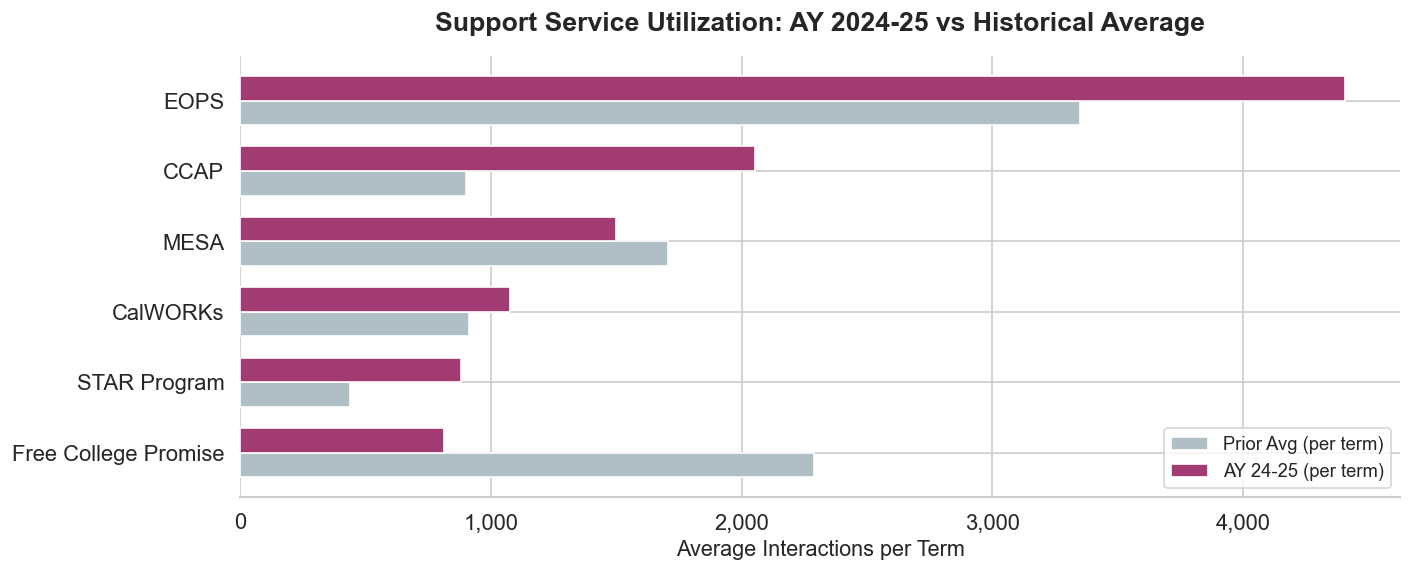

In [22]:
# ============================================================
# CHART 10: Service Growth - AY 24-25 vs Prior Average
# ============================================================
# METHOD: Grouped bar chart comparing per-term average
# interactions for each service. Normalizing by term count
# gives a fair apples-to-apples comparison.
# ============================================================

growth_data = []
for svc in services['Support_Services'].unique():
    svc_short = short_labels.get(svc, svc)
    ay_count = len(svc_ay[svc_ay['Support_Services'] == svc])
    prior_count = len(svc_prior[svc_prior['Support_Services'] == svc])
    n_ay_terms = max(svc_ay['Term'].nunique(), 1)
    n_prior_terms = max(svc_prior['Term'].nunique(), 1)
    growth_data.append({
        'Service': svc_short,
        'AY 24-25 (per term)': ay_count / n_ay_terms,
        'Prior Avg (per term)': prior_count / n_prior_terms
    })

growth_df = pd.DataFrame(growth_data).set_index('Service')
growth_df = growth_df.sort_values('AY 24-25 (per term)', ascending=True)

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(growth_df))
w = 0.35
ax.barh([i - w/2 for i in x], growth_df['Prior Avg (per term)'], height=w,
        label='Prior Avg (per term)', color='#B0BEC5', edgecolor='white')
ax.barh([i + w/2 for i in x], growth_df['AY 24-25 (per term)'], height=w,
        label='AY 24-25 (per term)', color='#A23B72', edgecolor='white')

ax.set_yticks(x)
ax.set_yticklabels(growth_df.index)
ax.set_xlabel('Average Interactions per Term')
ax.set_title('Support Service Utilization: AY 2024-25 vs Historical Average', pad=15)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

sns.despine(left=True)
plt.tight_layout()
plt.show()

---
## 6E. Grade Distribution Deep Dive

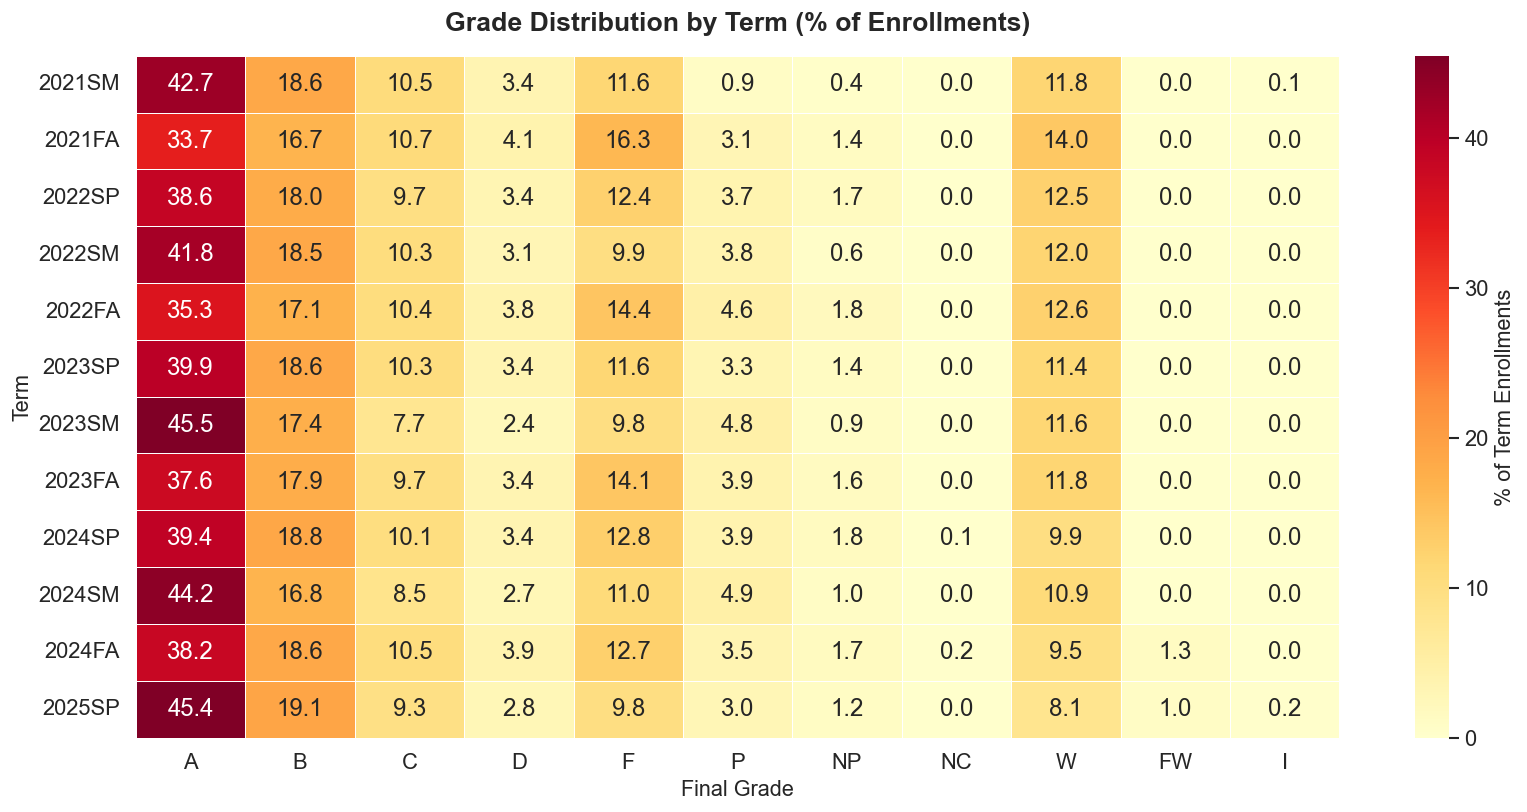

In [23]:
# ============================================================
# CHART 11: Grade Distribution Heatmap by Term
# ============================================================
# METHOD: Heatmap showing the percentage of each grade by term.
# This reveals subtle shifts in grading patterns over time —
# for example, whether F or W rates are increasing.
#
# ANALYTICAL NOTE: We normalize each term's row to 100% so
# terms with different enrollment volumes are comparable.
# ============================================================

# Create term x grade pivot
grade_order = ['A', 'B', 'C', 'D', 'F', 'P', 'CR', 'NP', 'NC', 'W', 'FW', 'I']
grade_by_term = g.groupby(['Term', 'Section_Final_Grade']).size().unstack(fill_value=0)
# Reorder columns
grade_by_term = grade_by_term[[c for c in grade_order if c in grade_by_term.columns]]
# Sort terms
grade_by_term['sort_key'] = grade_by_term.index.map(term_sort_key)
grade_by_term = grade_by_term.sort_values('sort_key').drop(columns='sort_key')

# Normalize to percentages per term
grade_pct = grade_by_term.div(grade_by_term.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(grade_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% of Term Enrollments'})
ax.set_title('Grade Distribution by Term (% of Enrollments)', pad=15)
ax.set_ylabel('Term')
ax.set_xlabel('Final Grade')
plt.tight_layout()
plt.show()

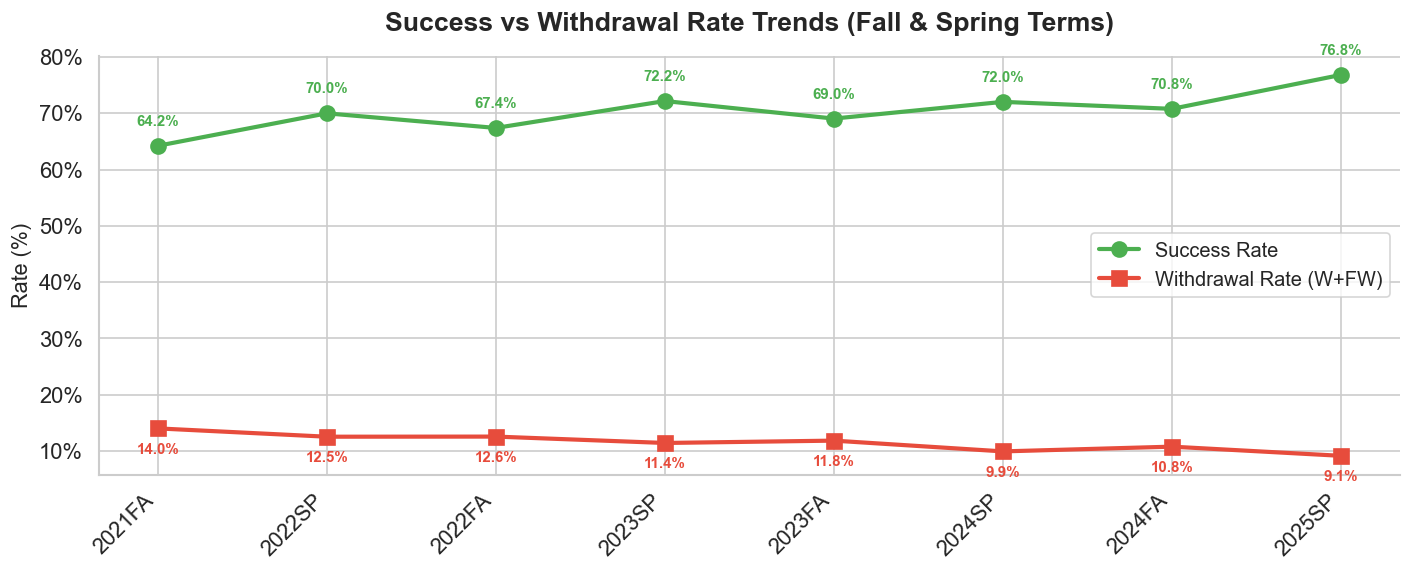

In [24]:
# ============================================================
# CHART 12: Success vs Withdrawal Rates — Trend Comparison
# ============================================================
# METHOD: Side-by-side line chart comparing success rate and
# withdrawal rate trends. An inverse relationship (success up,
# withdrawals down) would indicate improving retention.
#
# We focus on Fall/Spring terms for cleaner trend analysis.
# ============================================================

primary = term_stats[~term_stats['is_summer']].copy()
primary['withdrawal_rate'] = primary['Term'].map(
    lambda t: g[g['Term']==t]['Section_Final_Grade'].isin({'W','FW'}).mean()
)

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(primary))

ax.plot(x, primary['success_rate'] * 100, 'o-', color='#4CAF50',
        linewidth=2.5, markersize=9, label='Success Rate')
ax.plot(x, primary['withdrawal_rate'] * 100, 's-', color='#E74C3C',
        linewidth=2.5, markersize=9, label='Withdrawal Rate (W+FW)')

for i, row in primary.iterrows():
    idx = list(primary.index).index(i)
    ax.annotate(f"{row['success_rate']:.1%}", (idx, row['success_rate']*100),
                textcoords='offset points', xytext=(0, 12), ha='center',
                fontsize=9, fontweight='bold', color='#4CAF50')
    ax.annotate(f"{row['withdrawal_rate']:.1%}", (idx, row['withdrawal_rate']*100),
                textcoords='offset points', xytext=(0, -15), ha='center',
                fontsize=9, fontweight='bold', color='#E74C3C')

ax.set_xticks(x)
ax.set_xticklabels(primary['Term'], rotation=45, ha='right')
ax.set_ylabel('Rate (%)')
ax.set_title('Success vs Withdrawal Rate Trends (Fall & Spring Terms)', pad=15)
ax.legend(fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

sns.despine()
plt.tight_layout()
plt.show()

---
## 7. Methodology: What the Full Analysis Would Look Like

### With Clean Student IDs, We Would Perform:

**Step 1 — Identify First-Time Students (FTS)**
- For each student in AY 2024-2025 (2024FA, 2025SP, 2024SM), check their enrollment history
- A student qualifies as FTS if they have NO enrollment records in the prior 3 academic years (AY 2021-22, 2022-23, 2023-24)
- This requires joining the grades file to itself on `stuid` and checking for prior-term activity

**Step 2 — Link FTS to Support Services**
- Join the identified FTS cohort to the support services file on `stuid` + `Term`
- Create a binary flag: "Used any support service" vs. "Did not use any support service"
- Also create service-specific flags and a count of distinct services used

**Step 3 — Compare Course Outcomes**
- Join FTS to the enrollment/grades file on `stuid` + `Term` to get their course outcomes
- Compare success rates, completion rates, and withdrawal rates between:
  - FTS who used support services vs. FTS who did not
  - FTS by number of services used (dose-response)
  - FTS by specific service type (EOPS, MESA, CalWORKs, etc.)
  - FTS by timing of service engagement (before vs. during enrollment)

**Step 4 — Control for Demographics**
- Join FTS to demographics on `stuid` to get gender, race/ethnicity, first-gen status
- Stratify the service-outcome analysis by demographic subgroups to check for equity gaps
- Use logistic regression to estimate the association between service usage and success while controlling for demographics and academic program

**Step 5 — Statistical Testing**
- Chi-square tests for independence between service usage and success (categorical)
- Logistic regression for adjusted odds ratios
- Effect sizes and confidence intervals
- Propensity score matching to reduce selection bias (students who seek services may differ systematically from those who don't)

### Recommended Data Fix
- Re-export the CSV files from the source database with student IDs formatted as **text** (not numbers)
- Alternatively, open the source Excel files and format the `stuid` column as "Text" before saving to CSV
- This single fix would unlock the complete analysis described above

---
## 8. Key Findings & Recommendations

### Key Findings

1. **Institutional Success Rate is Strong:** The overall course success rate across all terms is approximately 71%, with completion rates near 89%. This indicates that when students complete courses, the vast majority are passing.

2. **Modality Matters for Success:** In-person and hybrid modalities consistently show different success and withdrawal patterns than fully online courses. This suggests that modality-specific support interventions may be warranted.

3. **Support Services Are Well-Utilized:** Over 118,000 student-term service interactions are recorded across 6 programs. EOPS is the most utilized program, followed by Free College Promise.

4. **Student Population is Predominantly Hispanic and First-Generation:** Over 67% of students identify as Hispanic, and 48% are first-generation college students. Support services should be culturally responsive and tailored to first-gen needs.

5. **Withdrawals Are a Significant Concern:** W and FW grades represent a meaningful portion of enrollments. Reducing withdrawals is a high-impact lever for improving overall success rates.

6. **Data Quality Requires Immediate Attention:** The corrupted student IDs prevent the most impactful analysis — directly linking support service participation to individual student outcomes.

### Recommendations

1. **Fix the Student ID Data:** Re-extract CSVs with IDs formatted as text. This single action unlocks the complete FTS-to-outcome analysis.

2. **Invest in Early-Term Interventions:** Given the withdrawal rate, consider proactive outreach to students in weeks 2-4 of the term, particularly in modalities with higher withdrawal rates.

3. **Expand High-Impact Services:** Once clean data confirms which services are most associated with improved outcomes, consider expanding those programs to reach more first-time students.

4. **Monitor Equity Gaps:** With clean data, stratify success rates by demographics AND service usage to ensure support programs are equitably benefiting all student populations.

5. **Standardize Data Governance:** Implement data export protocols that prevent future ID truncation issues across institutional research workflows.

---
*Analysis prepared for SBVC upper management. All original data files are unmodified. This notebook creates no new data files — all outputs are generated in-memory and displayed inline.*